Name-Riya choudhary

Subject-Computer vision Lab

CUID-CU24250251

**Experiment No. 4**

Frequency Domain Image Filtering using Fourier Transform

Saving input.jpg to input (1).jpg
Image loaded successfully!
Image: input (1).jpg
Grayscale image shape: (1080, 720)
Image data type: uint8


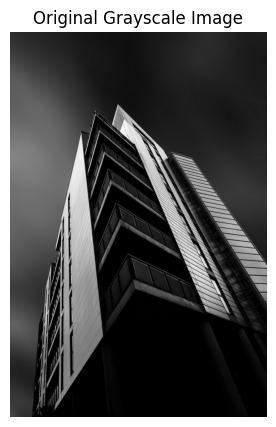

In [11]:
# Step 1: Import the required libraries and load a grayscale image

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

IMAGE_PATH = list(uploaded.keys())[0]

img = cv2.imread(IMAGE_PATH)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image loaded successfully!")
    print("Image:", IMAGE_PATH)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rows, cols = gray.shape

print("Grayscale image shape:", gray.shape)
print("Image data type:", gray.dtype)

plt.figure(figsize=(8, 5))
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [12]:
# Step 2: Compute the Discrete Fourier Transform (DFT)

dft = cv2.dft(
    np.float32(gray),
    flags=cv2.DFT_COMPLEX_OUTPUT
)

print("Discrete Fourier Transform (DFT) computed successfully.")

Discrete Fourier Transform (DFT) computed successfully.


In [13]:
# Step 3: Shift the zero-frequency component to the center

dft_shift = np.fft.fftshift(dft)

print("Zero-frequency component shifted to the center.")

Zero-frequency component shifted to the center.


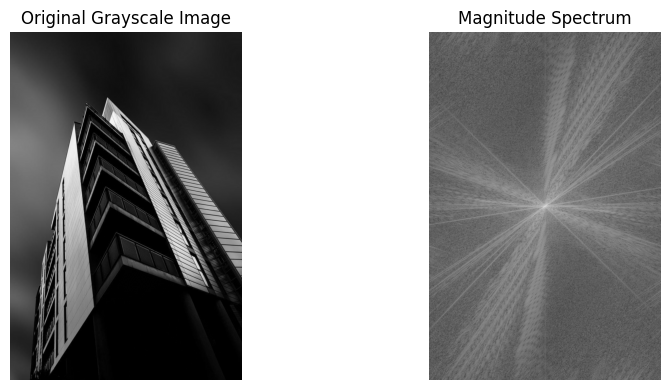

Frequency Spectrum Stats
-------------------------
Magnitude spectrum range: [48.34, 350.46]


In [14]:
# Step 4: Display and analyze the magnitude spectrum

magnitude_spectrum = 20 * np.log(
    cv2.magnitude(
        dft_shift[:, :, 0],
        dft_shift[:, :, 1]
    ) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Original Grayscale Image")
axes[0].axis("off")

axes[1].imshow(magnitude_spectrum, cmap="gray")
axes[1].set_title("Magnitude Spectrum")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Frequency Spectrum Stats")
print("-------------------------")
print(
    f"Magnitude spectrum range: "
    f"[{magnitude_spectrum.min():.2f}, "
    f"{magnitude_spectrum.max():.2f}]"
)

In [15]:
# Step 5: Design and apply a Low-Pass Frequency Filter

def circular_mask(shape, radius, low_pass=True):
    rows, cols = shape

    center_r, center_c = rows // 2, cols // 2

    y, x = np.ogrid[:rows, :cols]

    dist = np.sqrt(
        (y - center_r) ** 2 +
        (x - center_c) ** 2
    )

    mask = (dist <= radius).astype(np.float32)

    if not low_pass:
        mask = 1 - mask

    return np.stack([mask, mask], axis=-1)


RADIUS = 30

lp_mask = circular_mask(
    (rows, cols),
    RADIUS,
    low_pass=True
)

lp_dft_shift = dft_shift * lp_mask

print("Low-Pass Frequency Filter applied.")

Low-Pass Frequency Filter applied.


In [16]:
# Step 6: Design and apply a High-Pass Frequency Filter

hp_mask = circular_mask(
    (rows, cols),
    RADIUS,
    low_pass=False
)

hp_dft_shift = dft_shift * hp_mask

print("High-Pass Frequency Filter applied.")

High-Pass Frequency Filter applied.


In [17]:
# Step 7: Perform the Inverse Fourier Transform (IDFT)

def reconstruct(shifted_dft):
    unshifted = np.fft.ifftshift(shifted_dft)

    reconstructed = cv2.idft(unshifted)

    reconstructed = cv2.magnitude(
        reconstructed[:, :, 0],
        reconstructed[:, :, 1]
    )

    return cv2.normalize(
        reconstructed,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)


low_pass_result = reconstruct(lp_dft_shift)
high_pass_result = reconstruct(hp_dft_shift)

print("Inverse Fourier Transform (IDFT) completed successfully.")

Inverse Fourier Transform (IDFT) completed successfully.


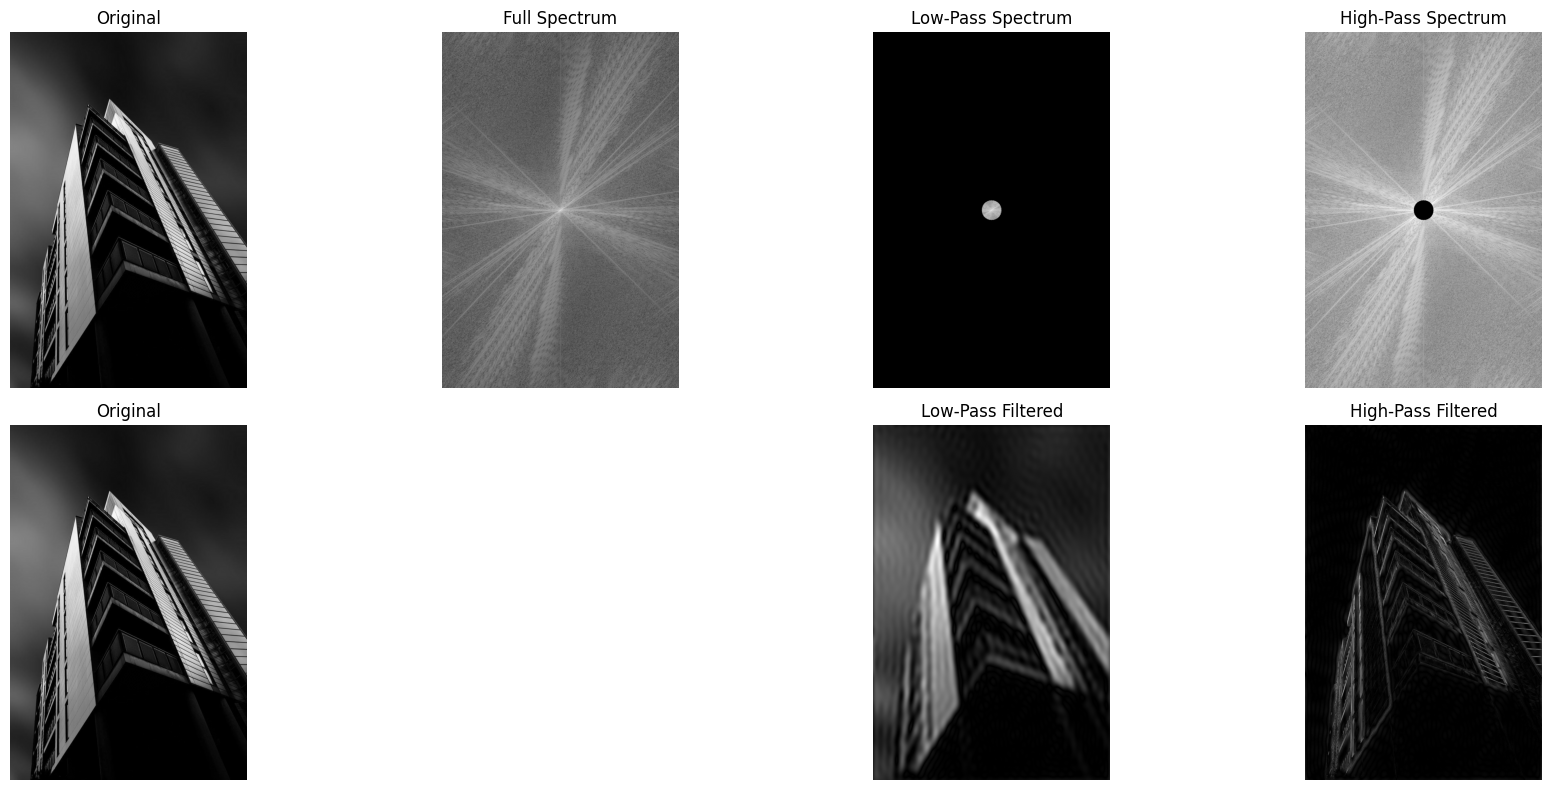

In [18]:
# Step 8: Compare original, spectrum, low-pass, and high-pass results

lp_spectrum = 20 * np.log(
    cv2.magnitude(
        lp_dft_shift[:, :, 0],
        lp_dft_shift[:, :, 1]
    ) + 1
)

hp_spectrum = 20 * np.log(
    cv2.magnitude(
        hp_dft_shift[:, :, 0],
        hp_dft_shift[:, :, 1]
    ) + 1
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes[0, 0].imshow(gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(magnitude_spectrum, cmap="gray")
axes[0, 1].set_title("Full Spectrum")
axes[0, 1].axis("off")

axes[0, 2].imshow(lp_spectrum, cmap="gray")
axes[0, 2].set_title("Low-Pass Spectrum")
axes[0, 2].axis("off")

axes[0, 3].imshow(hp_spectrum, cmap="gray")
axes[0, 3].set_title("High-Pass Spectrum")
axes[0, 3].axis("off")

axes[1, 0].imshow(gray, cmap="gray")
axes[1, 0].set_title("Original")
axes[1, 0].axis("off")

axes[1, 1].axis("off")

axes[1, 2].imshow(low_pass_result, cmap="gray")
axes[1, 2].set_title("Low-Pass Filtered")
axes[1, 2].axis("off")

axes[1, 3].imshow(high_pass_result, cmap="gray")
axes[1, 3].set_title("High-Pass Filtered")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Step 9: Analyze the impact on smoothness, edges, and noise

print("\nQuantitative Comparison")
print("-----------------------")

print(f"{'Image':20s} | {'Mean':8s} | {'Std':8s}")

print(
    f"{'Original':20s} | "
    f"{gray.mean():8.2f} | "
    f"{gray.std():8.2f}"
)

print(
    f"{'Low-Pass Filtered':20s} | "
    f"{low_pass_result.mean():8.2f} | "
    f"{low_pass_result.std():8.2f}"
)

print(
    f"{'High-Pass Filtered':20s} | "
    f"{high_pass_result.mean():8.2f} | "
    f"{high_pass_result.std():8.2f}"
)

print(
    f"\nLow-pass cutoff radius: {RADIUS} px "
    f"(retains low frequencies -> smoothing)"
)

print(
    f"High-pass cutoff radius: {RADIUS} px "
    f"(removes low frequencies -> edge/detail emphasis)"
)


Quantitative Comparison
-----------------------
Image                | Mean     | Std     
Original             |    52.42 |    58.89
Low-Pass Filtered    |    48.08 |    47.98
High-Pass Filtered   |    12.78 |    23.37

Low-pass cutoff radius: 30 px (retains low frequencies -> smoothing)
High-pass cutoff radius: 30 px (removes low frequencies -> edge/detail emphasis)


In [20]:
# Step 10: Document the observations

print("\nObservations")
print("------------")

print(
    "- The magnitude spectrum shows most energy concentrated "
    "near the center, representing low-frequency components."
)

print(
    "- Shifting the zero-frequency component to the center "
    "makes the spectrum easier to analyze and filter."
)

print(
    "- The Low-Pass Filter retains low frequencies and produces "
    "a smoothed or blurred image, reducing noise and fine details."
)

print(
    "- The High-Pass Filter removes low frequencies and keeps "
    "high-frequency components, emphasizing edges and fine details."
)

print(
    "- Frequency domain filtering allows selective manipulation "
    "of frequency components using a cutoff radius."
)

print(
    "- It is useful for image enhancement, noise reduction, "
    "edge detection, and image restoration."
)

print(
    "- Applications include medical image enhancement, satellite "
    "image analysis, image restoration, and biometric systems."
)


Observations
------------
- The magnitude spectrum shows most energy concentrated near the center, representing low-frequency components.
- Shifting the zero-frequency component to the center makes the spectrum easier to analyze and filter.
- The Low-Pass Filter retains low frequencies and produces a smoothed or blurred image, reducing noise and fine details.
- The High-Pass Filter removes low frequencies and keeps high-frequency components, emphasizing edges and fine details.
- Frequency domain filtering allows selective manipulation of frequency components using a cutoff radius.
- It is useful for image enhancement, noise reduction, edge detection, and image restoration.
- Applications include medical image enhancement, satellite image analysis, image restoration, and biometric systems.
